In [42]:
import torch
import numpy as np
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from tqdm import tqdm
from joblib import Parallel, delayed
from dadapy import data
import argparse
import json
import skdim
import sys
sys.path.append('src')
import importlib, extract_id
importlib.reload(extract_id)
from extract_id import load_model, shuffle_tokens, convert_to_distances, extract_hidden_states, convert_to_tensor
torch.set_grad_enabled(False)
print("Disabled automatic differentiation")
import matplotlib.pyplot as plt

Disabled automatic differentiation


In [41]:
# Install from GitHub master branch
!pip install git+https://github.com/scikit-learn-contrib/scikit-dimension.git@master

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/scikit-learn-contrib/scikit-dimension.git (to revision master) to /tmp/pip-req-build-dmu3f4vy
  Running command git clone --filter=blob:none --quiet https://github.com/scikit-learn-contrib/scikit-dimension.git /tmp/pip-req-build-dmu3f4vy
  Resolved https://github.com/scikit-learn-contrib/scikit-dimension.git to commit ba5d1b0d6f8643f112d60f94f3bad26497ddfebf
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'scikit-dimension' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'scikit-dimension'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel

In [2]:
model_name = 'meta-llama/Meta-Llama-3-8B'
device = torch.device('cuda')
model, tokenizer = load_model(model_name, device = device)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model 'meta-llama/Meta-Llama-3-8B' is available on Hugging Face.


In [4]:
ds = load_dataset("NeelNanda/pile-10k")['train']
sequences = ds['text']
max_length = 1024
filtered_indices = np.load('filtered_indices.npy')
filtered_sequences = [sequences[idx] for idx in filtered_indices]
max_length = 1024

In [32]:
# Extracting hidden states
PNUM = 686 # prompt number 3218
sequence = filtered_sequences[PNUM]
ans = extract_hidden_states(sequence, model, tokenizer, max_length)
hidden_distances = ans['hidden_distances'].squeeze()
hidden_states = ans['hidden_states'].squeeze()

In [33]:
# Extracting shuffled hidden states
inputs = tokenizer(sequence.strip(), add_special_tokens=False, return_tensors="pt",
                                       max_length=max_length, truncation=True).to(device)
ids = inputs['input_ids']
new_ids = shuffle_tokens(ids).to(device)
inputs = {'input_ids':new_ids}
outputs = model(**inputs, labels = inputs['input_ids'].clone(), output_hidden_states=True)
hidden_shuffled_distances = convert_to_distances(outputs.hidden_states).squeeze()
hidden_shuffled_states = convert_to_tensor(outputs.hidden_states).squeeze()

In [74]:
METHODS = {
    'TLE': skdim.id.TLE(),
    'ESS': skdim.id.ESS(),
    'GRIDE': None
}

def get_knn_from_torch_distance_matrix(dist_matrix: torch.Tensor, k: int):
    """
    dist_matrix: torch.Tensor of shape (N, N) — pairwise distances
    k: number of nearest neighbors to extract (excluding self-distance)

    Returns:
        knn_dists: np.ndarray of shape (N, k) with distances to k nearest neighbors
    """
    assert dist_matrix.shape[0] == dist_matrix.shape[1], "Distance matrix must be square"
    
    # Exclude the self-distance (0) by sorting and skipping the first column
    sorted_dists, sorted_neighbors = torch.sort(dist_matrix, dim=1)
    # print(sorted_neighbors)
    knn_dists = sorted_dists[:, 1:k+1]  # Exclude self (first entry)
    
    return sorted_dists[:, 1:k+1], sorted_neighbors[:, 1:k+1]  # Only this small part is moved to CPU

def compute_id_sigle_point_cloud(rep, dist_matrix, method):

    if method == 'ESS':
        knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=10)
        # print(knn_dists)
        knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        ess=skdim.id.ESS()
        return ess.fit_transform(rep.cpu().numpy(), precomputed_knn_arrays=[knn_dists, knn_neighbors])
        
    elif method == 'GRIDE':
        _data = data.Data(distances=dist_matrix.cpu().numpy(), maxk=100)
        return _data.return_id_scaling_gride(range_max=64)[0][1]
        
    if method == 'TLE':
        knn_dists, knn_neighbors = get_knn_from_torch_distance_matrix(dist_matrix, k=20)
        # print(knn_dists)
        knn_dists, knn_neighbors = knn_dists.double().cpu().numpy(), knn_neighbors.cpu().numpy()
        tle=skdim.id.TLE()
        return tle.fit_transform(rep.cpu().numpy(), precomputed_knn_arrays=[knn_dists, knn_neighbors])
    
    
def compute_ids(full_reps, full_distances, method):
    ids = []
    # Create a tqdm progress bar for the zip of full_reps and full_distances
    # Starting from index 1 for both iterables
    for rep, distance in tqdm(zip(full_reps[1:], full_distances[1:]), 
                             total=len(full_reps)-1,  # Set total to length-1 since we're skipping first layer or the embedding layer
                             desc=f"Computing IDs for {method}",    # Description for the progress bar
                             unit="sample"):          # Unit name
        ids.append(compute_id_sigle_point_cloud(rep, distance, method))
    return np.array(ids)

In [75]:
all_ids = {}
all_shuffled_ids = {}
for method in METHODS:
    all_ids[method] = compute_ids(hidden_states, hidden_distances, method)
    all_shuffled_ids[method] = compute_ids(hidden_shuffled_states, hidden_shuffled_distances, method)

Computing IDs for GRIDE: 100%|██████████| 32/32 [00:02<00:00, 14.34sample/s]


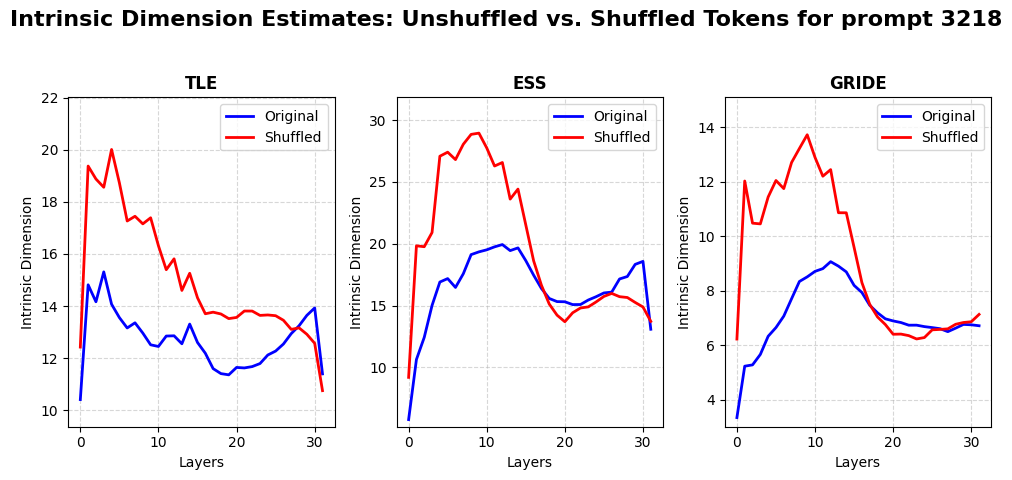

In [73]:
def plot_ids_line_comparison(all_ids, all_shuffled_ids, methods):
    # Set up the figure
    plt.figure(figsize=(10, 5))
    
    # Get the number of methods for grid layout
    n_methods = len(methods)
    n_cols = 3  # Number of columns in the grid
    n_rows = (n_methods + n_cols - 1) // n_cols  # Calculate needed rows
    
    # Plot each method in a separate subplot
    for i, method in enumerate(methods, 1):
        ax = plt.subplot(n_rows, n_cols, i)
        
        # Plot original IDs
        if method in all_ids:
            original_ids = all_ids[method]
            x_vals = np.arange(len(original_ids))
            ax.plot(x_vals, original_ids, 'b-', label='Original', linewidth=2)
            

        
        # Plot shuffled IDs
        if method in all_shuffled_ids:
            shuffled_ids = all_shuffled_ids[method]
            x_vals = np.arange(len(shuffled_ids))
            ax.plot(x_vals, shuffled_ids, 'r-', label='Shuffled', linewidth=2)

        
        # Set the title and labels
        ax.set_title(f'{method}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Layers')
        ax.set_ylabel('Intrinsic Dimension')
        
        # Add grid and legend
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best')
        
        # Adjust y-axis to ensure both lines are visible
        if method in all_ids and method in all_shuffled_ids:
            all_values = np.concatenate([original_ids, shuffled_ids])
            y_min = max(0, np.min(all_values) * 0.9)  # Ensure no negative values
            y_max = np.max(all_values) * 1.1  # Add 10% margin
            ax.set_ylim(y_min, y_max)
    
    # Add a global title
    plt.suptitle(f'Intrinsic Dimension Estimates: Unshuffled vs. Shuffled Tokens for prompt {filtered_indices[PNUM]}', 
                fontsize=16, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    return plt

# Usage:
fig = plot_ids_line_comparison(all_ids, all_shuffled_ids, list(METHODS.keys()))
# plt.savefig('id_estimators_comparison.png', dpi=300, bbox_inches='tight')
plt.show()